# Prepare environment

In [15]:
%reload_ext autoreload
%autoreload 2

import sys
from pathlib import Path

sys.path.append(str(Path.cwd().parent.parent))

# Load data

In [16]:
import torch

from src.dataset.digit import DigitDataModule


data_dir = "../../data/digit/"
batch_size = 32
num_workers = 0

torch.manual_seed(42)
dm = DigitDataModule(data_dir, batch_size=batch_size, num_workers=num_workers)
dm.prepare_data()
dm.setup()

# Analyze model

In [18]:
from src.model.digit_classifier import LitModel as DigitClassifier


checkpoint_path = "../../lightning_logs/version_0/checkpoints/epoch=0-step=1181.ckpt"

activations = {}
def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook

model = DigitClassifier.load_from_checkpoint(checkpoint_path)

for i, layer in enumerate(model.model.all_layers):
    layer.register_forward_hook(get_activation(f'layer_{i}_{layer.__class__.__name__}'))

features, labels = next(iter(dm.val_dataloader()))
logits = model(features)
loss = torch.nn.functional.cross_entropy(logits, labels)
loss.backward()

Initialized Conv2d with Kaiming Normal for weights and 0 for bias.
Initialized Conv2d with Kaiming Normal for weights and 0 for bias.
Initialized Linear with Xavier Uniform for weights and 0.01 for bias.
Initialized Linear with Xavier Uniform for weights and 0.01 for bias.


Activation norms:
Layer layer_0_Conv2d: 1.230
Layer layer_1_BatchNorm2d: 1.001
Layer layer_2_ReLU: 0.718
Layer layer_3_Dropout: 0.755
Layer layer_4_MaxPool2d: 1.068
Layer layer_5_Conv2d: 2.409
Layer layer_6_BatchNorm2d: 0.990
Layer layer_7_ReLU: 0.709
Layer layer_8_Dropout: 0.748
Layer layer_9_MaxPool2d: 1.153
Layer layer_10_Flatten: 1.153
Layer layer_11_Linear: 2.081
Layer layer_12_BatchNorm1d: 1.096
Layer layer_13_ReLU: 0.844
Layer layer_14_Dropout: 0.947
Layer layer_15_Linear: 3.073
Plotting Linear activations...
Layer 11: mean=-0.235, std=2.068
Layer 15: mean=-0.756, std=2.984


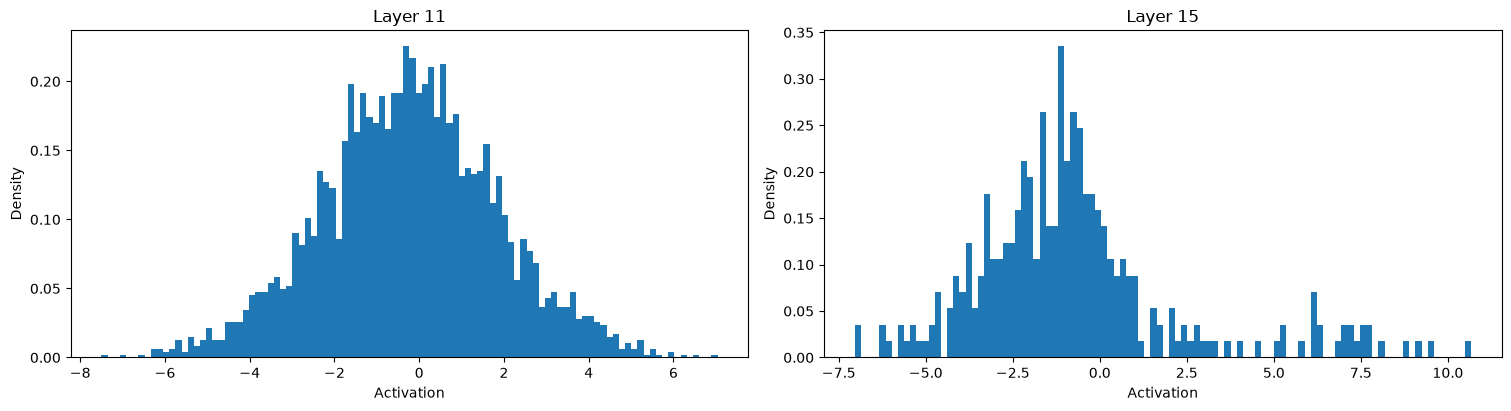

Plotting BatchNorm activations...
Layer 1: mean=-0.015, std=1.001
Layer 6: mean=-0.001, std=0.990
Layer 12: mean=0.062, std=1.094


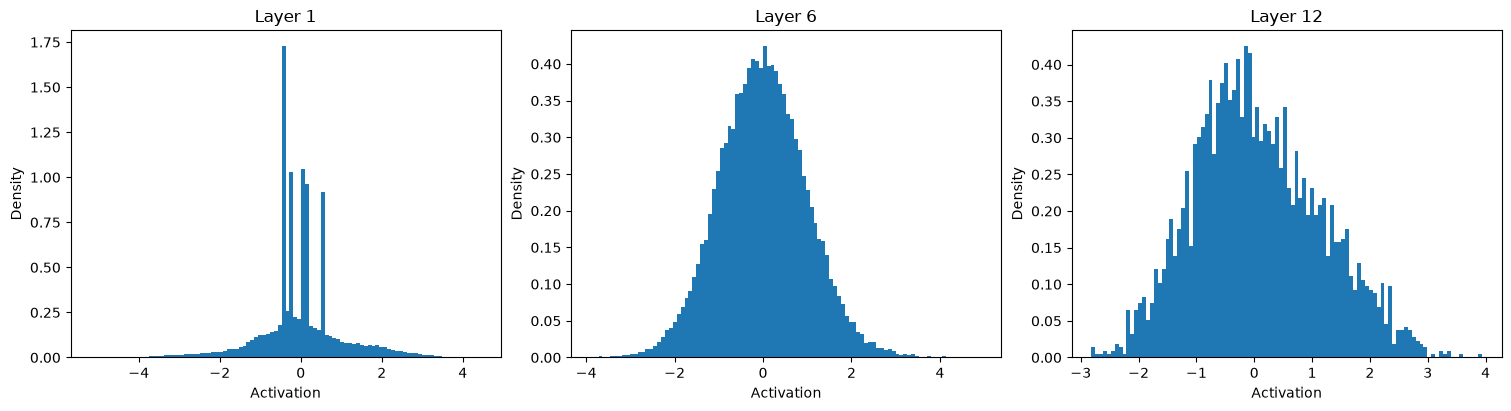

Plotting ReLU activations...
Layer 2: mean=0.331, std=0.636, zero=50.6%
Layer 7: mean=0.391, std=0.592, zero=50.6%
Layer 13: mean=0.473, std=0.700, zero=51.8%


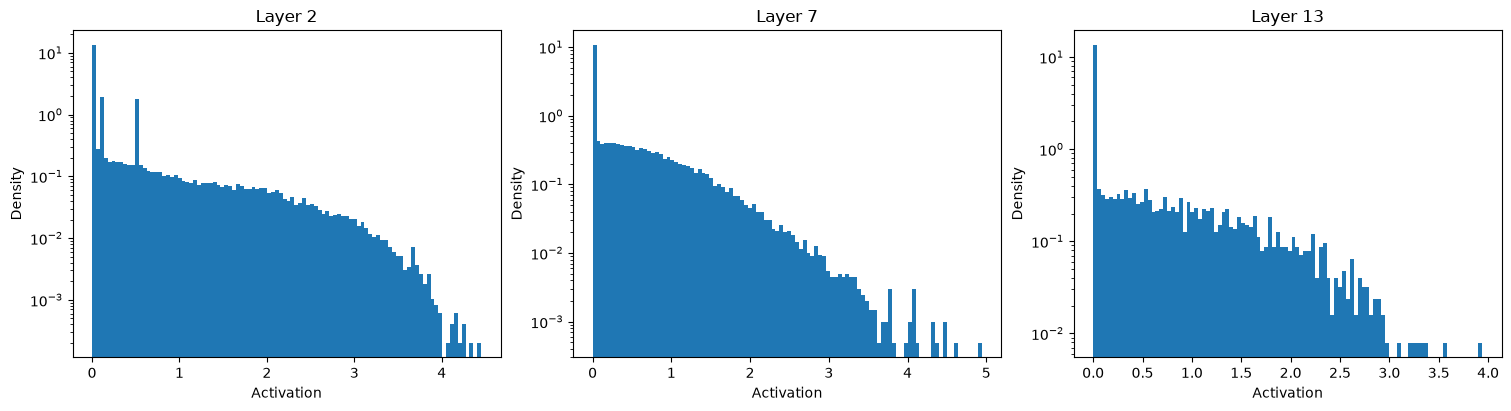

Gradient norms:
Parameter model.all_layers.0.weight: 0.077
Parameter model.all_layers.1.weight: 0.075
Parameter model.all_layers.1.bias: 0.036
Parameter model.all_layers.5.weight: 0.021
Parameter model.all_layers.6.weight: 0.025
Parameter model.all_layers.6.bias: 0.013
Parameter model.all_layers.11.weight: 0.006
Parameter model.all_layers.12.weight: 0.007
Parameter model.all_layers.12.bias: 0.009
Parameter model.all_layers.15.weight: 0.015
Parameter model.all_layers.15.bias: 0.021


In [22]:
%matplotlib inline
from src.plot import activations as plot

print("Activation norms:")
for i, activation in activations.items():
    print(f"Layer {i}: {activation.norm().item() / activation.numel()**0.5:.3f}")

print("Plotting Linear activations...")
plot.plot_linear_activations(model.model, activations)

print("Plotting BatchNorm activations...")
plot.plot_batchnorm_activations(model.model, activations)

print("Plotting ReLU activations...")
plot.plot_relu_activations(model.model, activations)

print("Gradient norms:")
for name, param in model.named_parameters():
    if param.grad is not None:
        print(f"Parameter {name}: {param.grad.norm().item() / param.grad.numel()**0.5:.3f}")